In [11]:
import pandas as pd
from pathlib import Path

DATASET = Path(r"C:\Users\user\Desktop\LUCY\AI Unleashed 2026\datasets\fer2013.csv")

In [12]:
df = pd.read_csv(DATASET)

print("Dataset loaded successfully.\n")

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()

display(df.head())

Dataset loaded successfully.

Shape: (35887, 3)
Columns: ['emotion', 'pixels', 'Usage']



,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training


In [13]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 35887 entries, 0 to 35886
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   emotion  35887 non-null  int64
 1   pixels   35887 non-null  str  
 2   Usage    35887 non-null  str  
dtypes: int64(1), str(2)
memory usage: 287.8 MB
None


In [14]:
emotion_names = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral",
}

distribution = (
    df["emotion"]
    .map(emotion_names)
    .value_counts()
    .sort_index()
)

print(distribution)

emotion
angry       4953
disgust      547
fear        5121
happy       8989
neutral     6198
sad         6077
surprise    4002
Name: count, dtype: int64


In [15]:
print(df["Usage"].value_counts())

Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


In [16]:
import numpy as np

invalid_length = []
invalid_range = []

for idx, pixel_string in enumerate(df["pixels"]):

    pixels = pixel_string.split()

    # Check number of pixels
    if len(pixels) != 2304:
        invalid_length.append(idx)
        continue

    pixels = np.array(pixels, dtype=np.int16)

    # Check pixel value range
    if pixels.min() < 0 or pixels.max() > 255:
        invalid_range.append(idx)

print("=" * 40)
print(f"Rows checked      : {len(df)}")
print(f"Invalid length    : {len(invalid_length)}")
print(f"Invalid range     : {len(invalid_range)}")

Rows checked      : 35887
Invalid length    : 0
Invalid range     : 0


In [19]:
import hashlib
from collections import defaultdict

hash_groups = defaultdict(list)

for idx, row in df.iterrows():
    pixel_hash = hashlib.md5(row["pixels"].encode()).hexdigest()

    hash_groups[pixel_hash].append({
        "index": idx,
        "emotion": row["emotion"],
        "usage": row["Usage"]
    })

duplicate_groups = {
    h: rows
    for h, rows in hash_groups.items()
    if len(rows) > 1
}

print("=" * 50)
print("Total unique images :", len(hash_groups))
print("Duplicate groups    :", len(duplicate_groups))
print("=" * 50)

Total unique images : 34034
Duplicate groups    : 1516


In [20]:
emotion_names = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

same_label = 0
cross_label = 0

for rows in duplicate_groups.values():

    labels = {r["emotion"] for r in rows}

    if len(labels) == 1:
        same_label += 1
    else:
        cross_label += 1

print(f"Same-label duplicate groups : {same_label}")
print(f"Cross-label duplicate groups: {cross_label}")

Same-label duplicate groups : 1459
Cross-label duplicate groups: 57


In [21]:
from collections import Counter

emotion_names = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral"
}

conflict_counter = Counter()

for rows in duplicate_groups.values():

    labels = sorted(set(r["emotion"] for r in rows))

    if len(labels) > 1:
        names = tuple(emotion_names[l] for l in labels)
        conflict_counter[names] += 1

print("=" * 60)
print("Cross-label conflict pairs")
print("=" * 60)

for pair, count in conflict_counter.most_common():
    print(f"{pair} : {count}")

Cross-label conflict pairs
('fear', 'surprise') : 12
('angry', 'sad') : 10
('angry', 'fear') : 8
('fear', 'sad') : 8
('fear', 'neutral') : 4
('happy', 'surprise') : 4
('sad', 'neutral') : 3
('angry', 'neutral') : 2
('angry', 'disgust') : 1
('angry', 'surprise') : 1
('disgust', 'fear') : 1
('angry', 'happy', 'sad', 'surprise', 'neutral') : 1
('disgust', 'surprise') : 1
('happy', 'neutral') : 1


Conflict: angry vs disgust


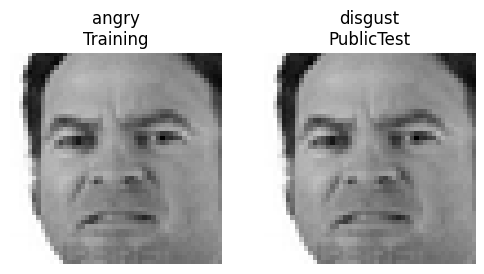

Conflict: angry vs sad


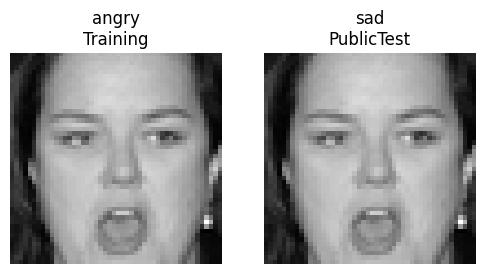

Conflict: angry vs fear


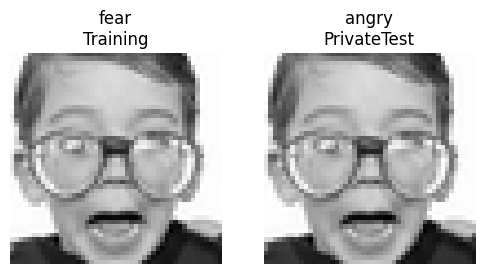

Conflict: fear vs neutral


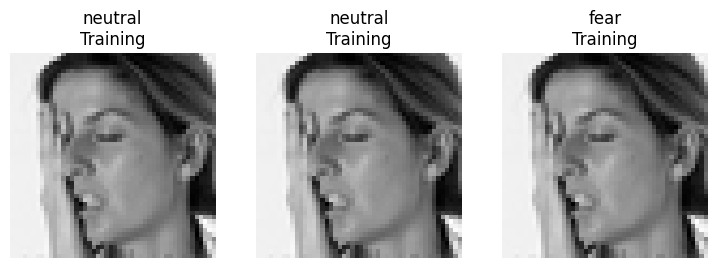

Conflict: fear vs sad


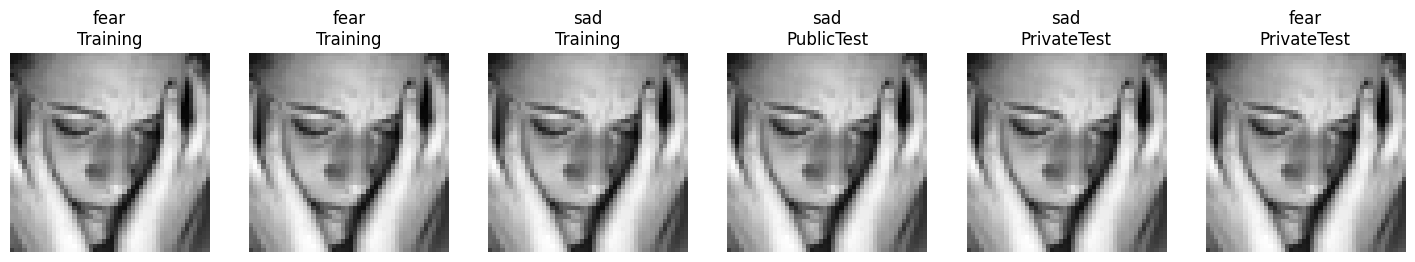

Conflict: fear vs surprise


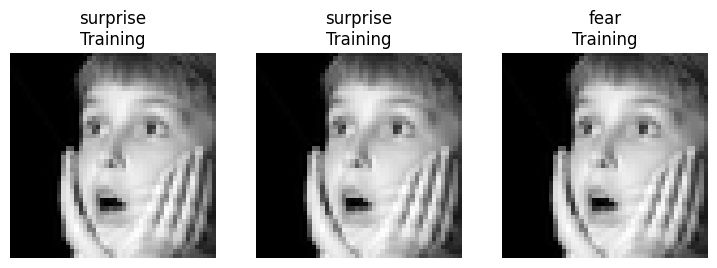

Conflict: sad vs neutral


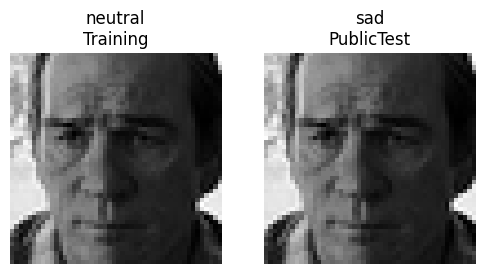

Conflict: angry vs neutral


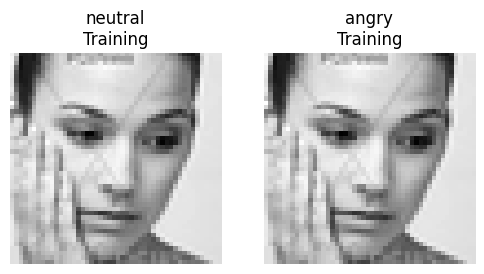

Conflict: happy vs surprise


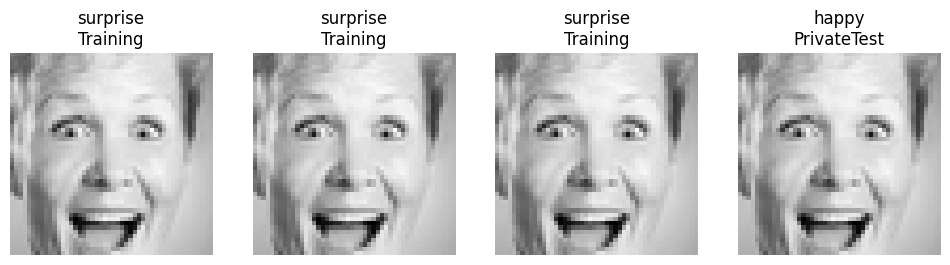

Conflict: angry vs surprise


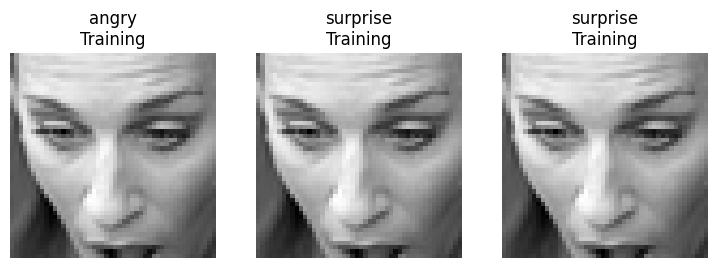

Conflict: disgust vs fear


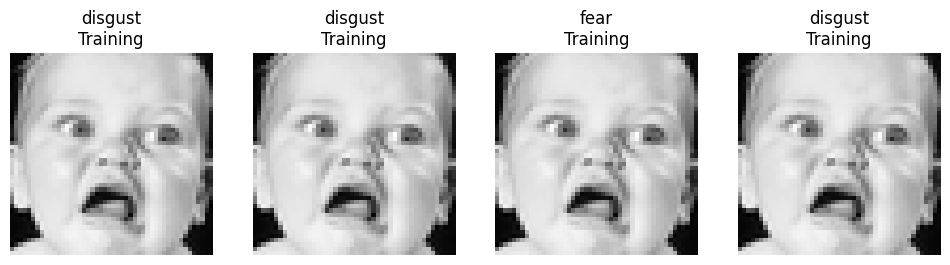

Conflict: angry vs happy vs sad vs surprise vs neutral


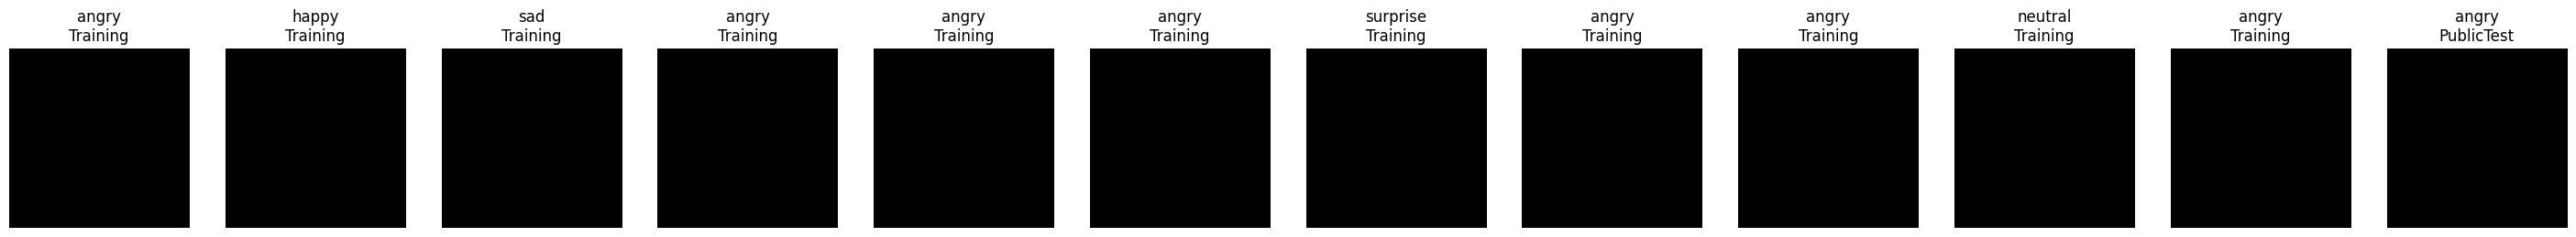

Conflict: disgust vs surprise


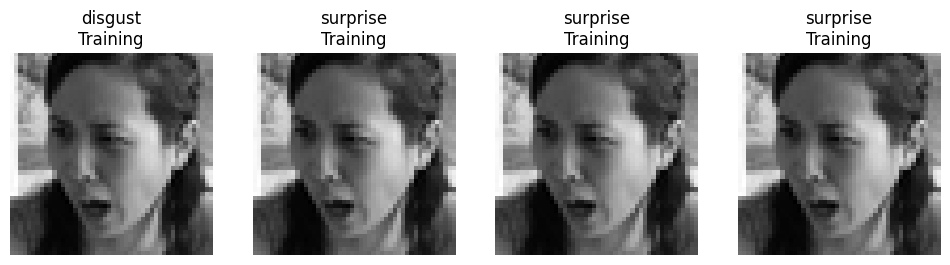

Conflict: happy vs neutral


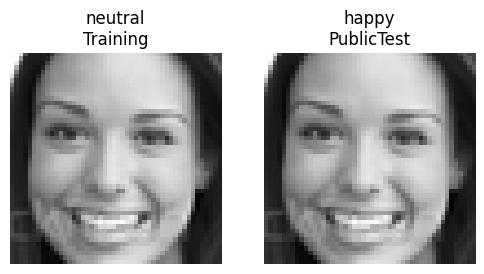

In [22]:
import numpy as np
import matplotlib.pyplot as plt

shown = set()

for rows in duplicate_groups.values():

    labels = sorted(set(r["emotion"] for r in rows))

    if len(labels) < 2:
        continue

    pair = tuple(labels)

    if pair in shown:
        continue

    shown.add(pair)

    print("=" * 80)
    print("Conflict:",
          " vs ".join(emotion_names[l] for l in pair))

    plt.figure(figsize=(3*len(rows),3))

    for i, r in enumerate(rows):

        pixels = np.fromstring(
            df.loc[r["index"], "pixels"],
            sep=" ",
            dtype=np.uint8
        ).reshape(48,48)

        plt.subplot(1,len(rows),i+1)
        plt.imshow(pixels, cmap="gray")
        plt.axis("off")
        plt.title(
            f"{emotion_names[r['emotion']]}\n{r['usage']}"
        )

    plt.show()

In [23]:
import numpy as np

black_images = []

for idx, row in df.iterrows():

    pixels = np.fromstring(row["pixels"], sep=" ", dtype=np.uint8)

    # Completely black image
    if np.all(pixels == 0):
        black_images.append(idx)

print(f"Completely black images: {len(black_images)}")

if black_images:
    print("\nFirst few indices:")
    print(black_images[:20])

Completely black images: 12

First few indices:
[6458, 7629, 10423, 11286, 13148, 13402, 13988, 15894, 22198, 22927, 28601, 30002]


In [24]:
dark_images = []

for idx, row in df.iterrows():

    pixels = np.fromstring(row["pixels"], sep=" ", dtype=np.uint8)

    mean_intensity = pixels.mean()

    if mean_intensity < 5:
        dark_images.append((idx, mean_intensity))

print(f"Very dark images (<5 mean intensity): {len(dark_images)}")

print("\nFirst 20:")
for item in dark_images[:20]:
    print(item)

Very dark images (<5 mean intensity): 12

First 20:
(6458, np.float64(0.0))
(7629, np.float64(0.0))
(10423, np.float64(0.0))
(11286, np.float64(0.0))
(13148, np.float64(0.0))
(13402, np.float64(0.0))
(13988, np.float64(0.0))
(15894, np.float64(0.0))
(22198, np.float64(0.0))
(22927, np.float64(0.0))
(28601, np.float64(0.0))
(30002, np.float64(0.0))


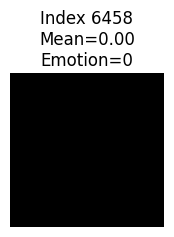

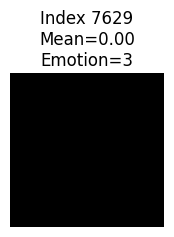

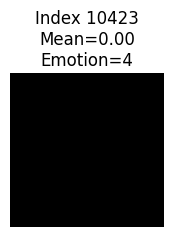

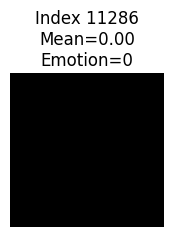

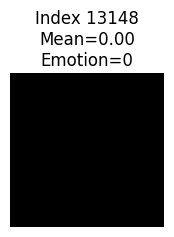

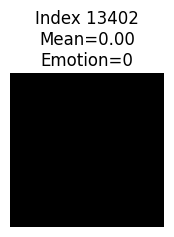

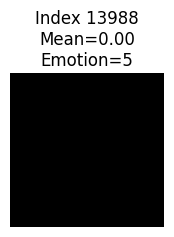

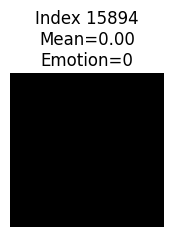

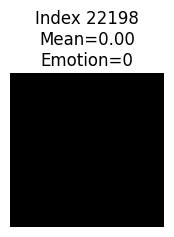

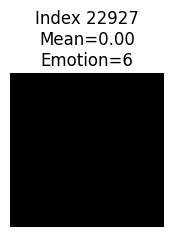

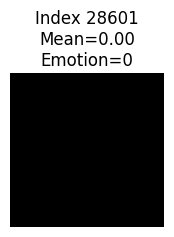

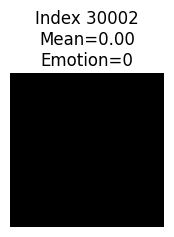

In [25]:
import matplotlib.pyplot as plt

for idx, mean in dark_images[:12]:

    pixels = np.fromstring(
        df.loc[idx, "pixels"],
        sep=" ",
        dtype=np.uint8
    ).reshape(48,48)

    plt.figure(figsize=(2,2))
    plt.imshow(pixels, cmap="gray")
    plt.title(
        f"Index {idx}\nMean={mean:.2f}\nEmotion={df.loc[idx,'emotion']}"
    )
    plt.axis("off")
    plt.show()

In [26]:
emotion_names = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "surprise",
    6: "neutral",
}

for idx in black_images:
    print(
        f"Index: {idx:5d} | "
        f"Emotion: {emotion_names[df.loc[idx, 'emotion']]:9s} | "
        f"Usage: {df.loc[idx, 'Usage']}"
    )

Index:  6458 | Emotion: angry     | Usage: Training
Index:  7629 | Emotion: happy     | Usage: Training
Index: 10423 | Emotion: sad       | Usage: Training
Index: 11286 | Emotion: angry     | Usage: Training
Index: 13148 | Emotion: angry     | Usage: Training
Index: 13402 | Emotion: angry     | Usage: Training
Index: 13988 | Emotion: surprise  | Usage: Training
Index: 15894 | Emotion: angry     | Usage: Training
Index: 22198 | Emotion: angry     | Usage: Training
Index: 22927 | Emotion: neutral   | Usage: Training
Index: 28601 | Emotion: angry     | Usage: Training
Index: 30002 | Emotion: angry     | Usage: PublicTest


In [27]:
from pathlib import Path
import pandas as pd

# Original CSV
CSV_PATH = Path(r"C:\Users\user\Desktop\LUCY\AI Unleashed 2026\datasets\fer2013.csv")

# Output CSV
OUTPUT_PATH = Path(r"C:\Users\user\Desktop\LUCY\AI Unleashed 2026\datasets\fer2013_clean.csv")

# Load dataset
df = pd.read_csv(CSV_PATH)

# Indices of confirmed black images
black_images = [
    6458,
    7629,
    10423,
    11286,
    13148,
    13402,
    13988,
    15894,
    22198,
    22927,
    28601,
    30002
]

print(f"Original dataset size : {len(df)}")

# Remove black images
df_clean = df.drop(index=black_images).reset_index(drop=True)

print(f"Removed images        : {len(black_images)}")
print(f"New dataset size      : {len(df_clean)}")

# Save cleaned dataset
df_clean.to_csv(OUTPUT_PATH, index=False)

print(f"\nClean dataset saved to:\n{OUTPUT_PATH}")

Original dataset size : 35887
Removed images        : 12
New dataset size      : 35875

Clean dataset saved to:
C:\Users\user\Desktop\LUCY\AI Unleashed 2026\datasets\fer2013_clean.csv
